In [1]:
%load_ext autoreload
%autoreload 2
import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
import os
import networkx as nx
from networkx.algorithms.connectivity import edge_connectivity
import re
from pathlib import Path


sys.setrecursionlimit(10**6)
warnings.filterwarnings('ignore')
datadir = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_ConstantStress/Data/'
plotsdir = '//Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_ConstantStress/Plots/'
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs3 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84']

cmap3 = plt.cm.get_cmap('BuPu')
cmap3 = plt.cm.get_cmap('twilight')
cmap3 = plt.cm.get_cmap('PiYG')

In [2]:
Presses = "-0.1".split()
#Presses = "-0.05".split()
MPs = "0.0 0.01 0.01".split() #0.1 0.01 0.001 0.0001 0.00001 0.00001 
labels = ["i. No bond remodelling","ii. Remodel no new material","iii. Remodel + new material"]
NuMons = "5 5 5".split()
lw = 2
cmap = plt.get_cmap('magma')
lines = ['-',':','--','-.']
clrs = ['#fdae61','#2b83ba','#abdda4']
cmap = plt.get_cmap('magma')

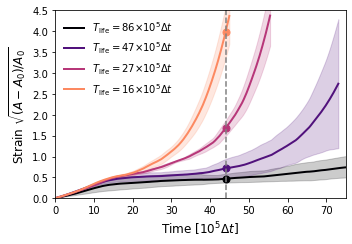

In [3]:
def plot_strain_4conditions_from_files(
    datadir,
    lifetimes_round,
    frames,
    cmap,
    x_ref=44.0,              # where you place the marker (in 1e5 Δt units)
    lw=2,
    figsize=(5, 3.5),
):
    """
    Reads 4 files with columns:
      Time AvStrain StdStrain Time_1e5
    and reproduces your original plotting style.
    """
    fig, ax = plt.subplots(figsize=figsize)

    files = sorted(Path(datadir).glob("Strain_condition*_Tlife_*x1e5dt.dat"))
    if len(files) != 4:
        raise RuntimeError(f"Expected 4 files, found {len(files)}")

    for ii, fp in enumerate(files):
        df = pandas.read_csv(fp, sep=r"\s+", engine="python")

        t1e5 = df["Time_1e5"].to_numpy(dtype=float)
        strain = df["AvStrain"].to_numpy(dtype=float)
        std = df["StdStrain"].to_numpy(dtype=float)

        color = cmap(ii / 4.0)

        # mean line
        ax.plot(
            t1e5,
            strain,
            color=color,
            linewidth=lw,
            label=(
                r"$T_{\mathrm{life}}=$"
                + str(int(lifetimes_round[ii]))
                + r"$\times10^5\Delta t$"
            ),
        )

        # ±1 std band
        ax.fill_between(
            t1e5,
            strain - std,
            strain + std,
            color=color,
            alpha=0.2,
        )

        # marker at reference time
        arg_time = np.argmin(np.abs(t1e5 - x_ref))
        ax.plot(
            t1e5[arg_time],
            strain[arg_time],
            marker="o",
            color=color,
            markersize=7,
        )

    # vertical reference line (same as your original)
    ax.plot([x_ref, x_ref], [0, 5], linestyle="--", color="grey")

    # labels and limits (matching your script)
    ax.set_ylabel(r"Strain $\sqrt{(A-A_{0})/A_{0}}$", fontsize=12)
    ax.set_xlabel(r"Time [$10^5\Delta t$]", fontsize=12)
    ax.set_xlim([0, 75])
    ax.set_ylim([0, 4.5])

    ax.legend(frameon=False)
    fig.tight_layout()
    return fig, ax


# -------- Example usage --------
data_dir = Path(datadir)

lifetimes = np.array([
    8580699.284143684,
    4706247.437784363,
    2661235.159674766,
    1566475.77837646,
])
LifeTimeRound = np.round(lifetimes / 1e5).astype(int)

frames = [200, 200, 200, 200]

fig, ax = plot_strain_4conditions_from_files(
    datadir=data_dir,
    lifetimes_round=LifeTimeRound,
    frames=frames,
    cmap=cmap,
    x_ref=44.0,
)

fig.savefig(Path(plotsdir) / "Strain_Vs_4Lifetimes.pdf")
